# Malaria in Africa: Exploratory Data Analysis
### Tools: Python | Pandas | Matplotlib | Seaborn

## 1. Data Overview
Loading the dataset and understanding its structure

In [ ]:
import zipfile
zipfile.ZipFile('/content/archive (2) (1).zip', 'r').extractall('/content/')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/DatasetAfricaMalaria.csv')
df.head()

,Country Name,Year,Country Code,"Incidence of malaria (per 1,000 population at risk)",Malaria cases reported,Use of insecticide-treated bed nets (% of under-5 population),Children with fever receiving antimalarial drugs (% of children under age 5 with fever),Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women),People using safely managed drinking water services (% of population),"People using safely managed drinking water services, rural (% of rural population)",...,Urban population growth (annual %),People using at least basic drinking water services (% of population),"People using at least basic drinking water services, rural (% of rural population)","People using at least basic drinking water services, urban (% of urban population)",People using at least basic sanitation services (% of population),"People using at least basic sanitation services, rural (% of rural population)","People using at least basic sanitation services, urban (% of urban population)",latitude,longitude,geometry
0,Algeria,2007,DZA,0.01,26.0,NaN,NaN,NaN,NaN,NaN,...,2.71,91.68,85.83,94.78,85.85,76.94,90.57,28.033886,1.659626,POINT (28.033886 1.659626)
1,Angola,2007,AGO,286.72,1533485.0,18.0,29.8,1.5,NaN,NaN,...,5.01,47.96,23.77,65.83,37.26,14.00,54.44,-11.202692,17.873887,POINT (-11.202692 17.873887)
2,Benin,2007,BEN,480.24,0.0,NaN,NaN,NaN,NaN,NaN,...,4.09,63.78,54.92,76.24,11.80,4.29,22.36,9.307690,2.315834,POINT (9.307689999999999 2.315834)
3,Botswana,2007,BWA,1.03,390.0,NaN,NaN,NaN,NaN,NaN,...,4.80,78.89,57.60,94.35,61.60,39.99,77.30,-22.328474,24.684866,POINT (-22.328474 24.684866)
4,Burkina Faso,2007,BFA,503.80,44246.0,NaN,NaN,NaN,NaN,NaN,...,5.91,52.27,45.13,76.15,15.60,6.38,46.49,12.238333,-1.561593,POINT (12.238333 -1.561593)


In [ ]:
df.shape

(594, 27)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594 entries, 0 to 593
Data columns (total 27 columns):
 #   Column                                                                                   Non-Null Count  Dtype  
---  ------                                                                                   --------------  -----  
 0   Country Name                                                                             594 non-null    object 
 1   Year                                                                                     594 non-null    int64  
 2   Country Code                                                                             594 non-null    object 
 3   Incidence of malaria (per 1,000 population at risk)                                      550 non-null    float64
 4   Malaria cases reported                                                                   550 non-null    float64
 5   Use of insecticide-treated bed nets (% of under-5 population)   

In [ ]:
print(df.duplicated().sum())

0


In [ ]:
df.isnull().sum()

,0
Country Name,0
Year,0
Country Code,0
"Incidence of malaria (per 1,000 population at risk)",44
Malaria cases reported,44
Use of insecticide-treated bed nets (% of under-5 population),462
Children with fever receiving antimalarial drugs (% of children under age 5 with fever),472
Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women),488
People using safely managed drinking water services (% of population),495
"People using safely managed drinking water services, rural (% of rural population)",506


## 2. Data Cleaning
Removed columns with more than 50% missing values. Dataset reduced from 27 to 18 columns.

In [ ]:
# Drop columns with too many missing values
threshold = 0.5
df = df.dropna(thresh=len(df)*threshold, axis=1)
df.shape

(594, 18)

In [ ]:
# Check remaining missing values
df.isnull().sum().sort_values(ascending=False)

,0
Malaria cases reported,44
"Incidence of malaria (per 1,000 population at risk)",44
"People using at least basic sanitation services, urban (% of urban population)",28
"People using at least basic sanitation services, rural (% of rural population)",28
"People using at least basic drinking water services, urban (% of urban population)",28
"People using at least basic drinking water services, rural (% of rural population)",28
People using at least basic sanitation services (% of population),6
People using at least basic drinking water services (% of population),6
Rural population (% of total population),6
Rural population growth (annual %),6


In [ ]:
# Fill missing values with median
df.fillna(df.median(numeric_only=True), inplace=True)

#Confirm no more missing values
df.isnull().sum().sum()

np.int64(0)

## 3. Key Performance Indicators
High-level summary statistics of the dataset.

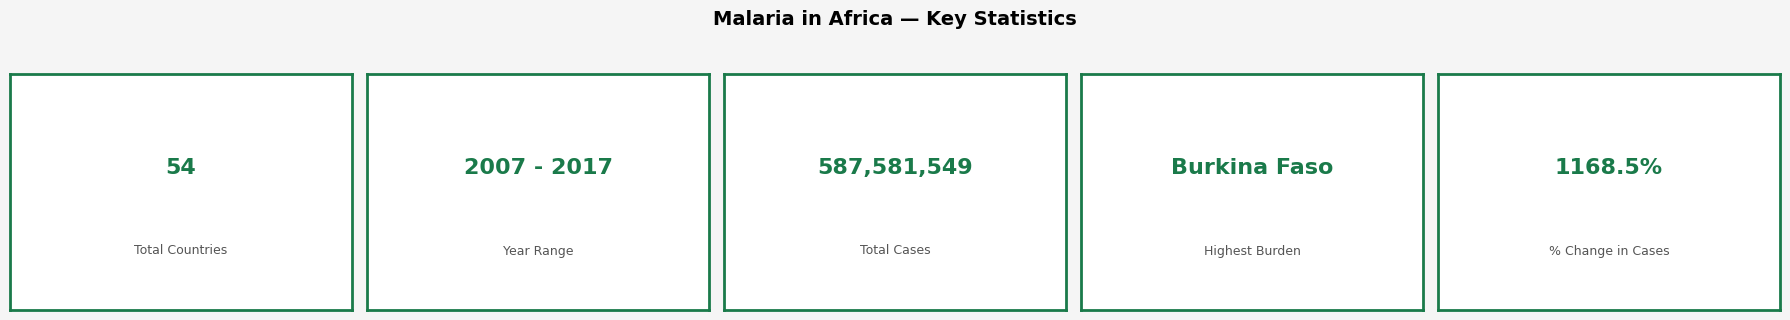

In [ ]:

# Calculate KPIs
total_countries = df['Country Name'].nunique()
year_range = f"{df['Year'].min()} - {df['Year'].max()}"
total_cases = df['Malaria cases reported'].sum()
highest_country = df.groupby('Country Name')['Incidence of malaria (per 1,000 population at risk)'].mean().idxmax()
cases_by_year = df.groupby('Year')['Malaria cases reported'].sum()
pct_change = ((cases_by_year.iloc[-1] - cases_by_year.iloc[0]) / cases_by_year.iloc[0]) * 100

# KPI Cards
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
fig.patch.set_facecolor('#f5f5f5')

kpis = [
    ("Total Countries", total_countries, ""),
    ("Year Range", year_range, ""),
    ("Total Cases", f"{total_cases:,.0f}", ""),
    ("Highest Burden", highest_country, ""),
    ("% Change in Cases", f"{pct_change:.1f}%", ""),
]

for ax, (title, value, unit) in zip(axes, kpis):
    ax.set_facecolor('#ffffff')
    ax.text(0.5, 0.6, str(value), ha='center', va='center',
            fontsize=16, fontweight='bold', color='#1a7a4a',
            transform=ax.transAxes)
    ax.text(0.5, 0.25, title, ha='center', va='center',
            fontsize=9, color='#555555',
            transform=ax.transAxes)
    for spine in ax.spines.values():
        spine.set_edgecolor('#1a7a4a')
        spine.set_linewidth(2)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Malaria in Africa — Key Statistics',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

##

## 4. Nigeria Focus
Analyzing malaria incidence trend in Nigeria over the years.

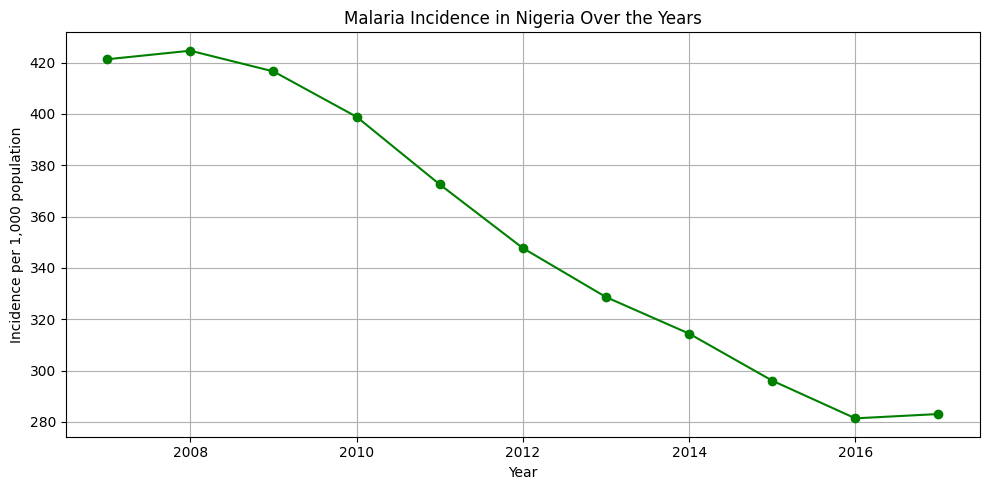

In [ ]:
# Filter Nigeria Data
nigeria = df[df['Country Name'] == 'Nigeria']

# Plot malaria incidence trend
plt.figure(figsize=(10, 5))
plt.plot(nigeria['Year'], nigeria['Incidence of malaria (per 1,000 population at risk)'], marker='o', color='green')
plt.title('Malaria Incidence in Nigeria Over the Years')
plt.xlabel('Year')
plt.ylabel('Incidence per 1,000 population')
plt.grid(True)
plt.tight_layout()
plt.show()

### Finding 1:
Nigeria recorded a 34% reduction in malaria incidence between 2008 and 2017, dropping from ~425 to ~280 cases per 1,000 population at risk.

## 5. Continental Comparison
Comparing malaria incidence across African countries.

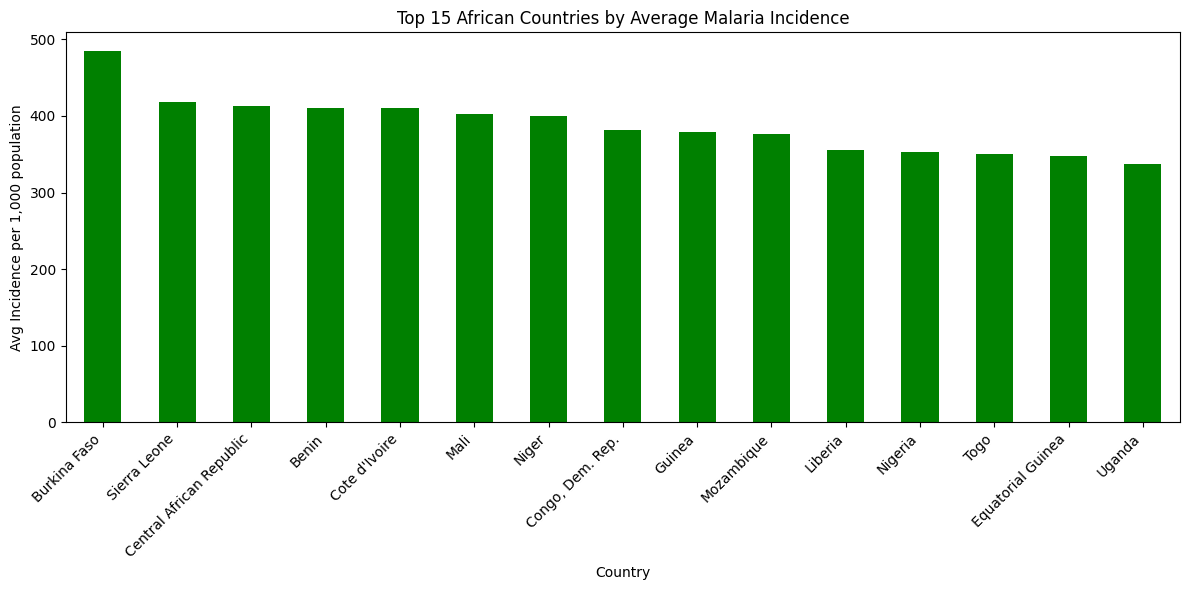

In [ ]:
# Get average malaria incidence per country
avg_incidence = df.groupby('Country Name')['Incidence of malaria (per 1,000 population at risk)'].mean().sort_values(ascending=False)

# Plot top 15 Countries
plt.figure(figsize=(12, 6))
avg_incidence.head(15).plot(kind='bar', color='green')
plt.title('Top 15 African Countries by Average Malaria Incidence')
plt.xlabel('Country')
plt.ylabel('Avg Incidence per 1,000 population')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Finding 2:
Burkina Faso records the highest average malaria incidence in africa.
Nigeria ranks among the top 15 highest-burden countries, alongside Sierra Leone, Central African Republic, and Mali.

## 6. Urban vs Rural Analysis
Exploring the relationship between population distribution and malaria incidence.

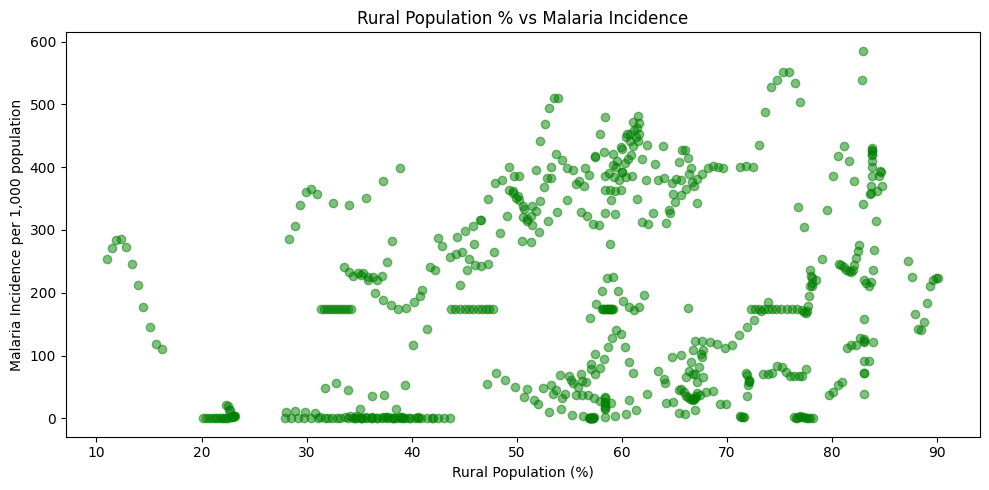

In [ ]:
# Average malaria incidence by rural vs urban population
plt.figure(figsize=(10, 5))
plt.scatter(df['Rural population (% of total population)'], df['Incidence of malaria (per 1,000 population at risk)'], color='green', alpha=0.5)
plt.title('Rural Population % vs Malaria Incidence')
plt.xlabel('Rural Population (%)')
plt.ylabel('Malaria Incidence per 1,000 population')
plt.tight_layout()
plt.show()

### Findings 3:
Countries with higher rural populations tends to record higher malaria incidence.
This suggests rural areas face greater exposure risk, likely due limited health care access and infrastructure.

##7. Water & Sanitation vs Malaria
Exploring whether access to clean water and sanitation affects malaria incidence.

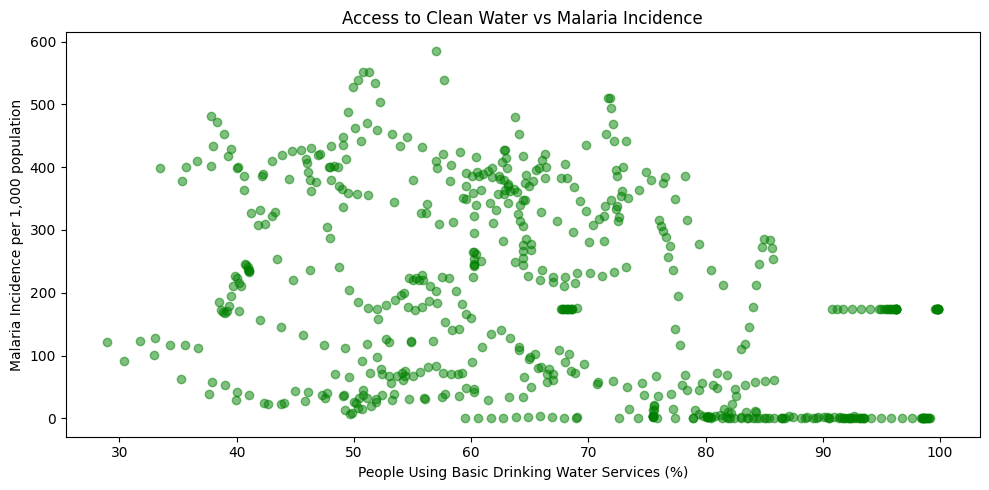

In [ ]:
# Water access vs Malaria Incidence
plt.figure(figsize=(10, 5))
plt.scatter(df['People using at least basic drinking water services (% of population)'], df['Incidence of malaria (per 1,000 population at risk)'], color='green', alpha=0.5)
plt.title('Access to Clean Water vs Malaria Incidence')
plt.xlabel('People Using Basic Drinking Water Services (%)')
plt.ylabel('Malaria Incidence per 1,000 population')
plt.tight_layout()
plt.show()

### Finding 4:
Countries with lower access to clean drinking water record significantly
higher malaria incidence. As water access approaches 100%,
malaria incidence drops sharply, highlighting the critical role
of clean water infrastructure in disease prevention.

## 8. Correlation Heatmap
Exploring relationships between all numerical variables.

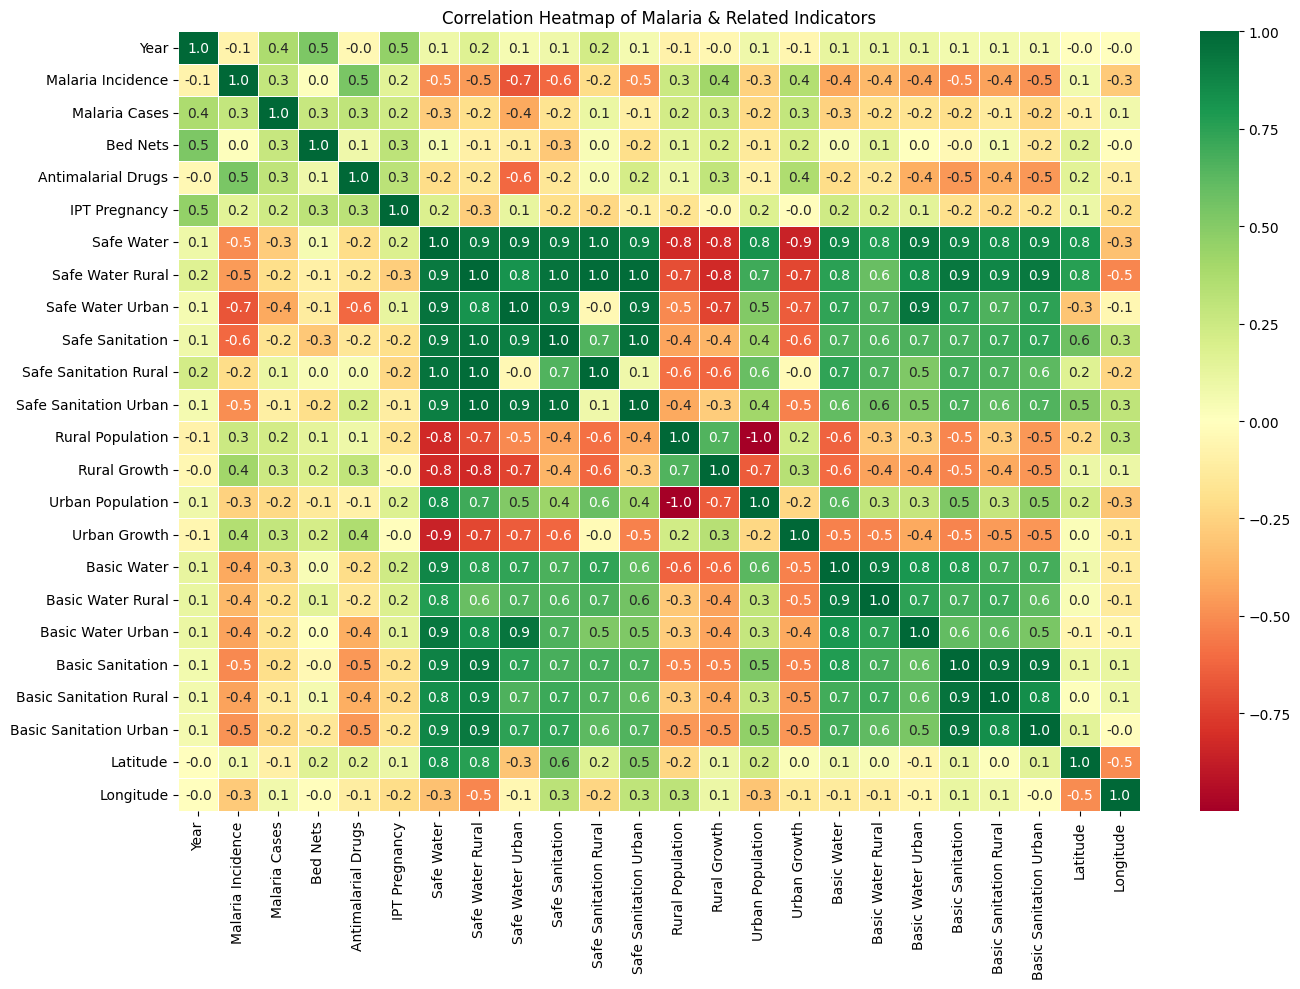

In [ ]:
# Shorten column names for heatmap
df_heat = df.copy()
df_heat.columns = [
    'Country', 'Year', 'Code',
    'Malaria Incidence', 'Malaria Cases',
    'Bed Nets', 'Antimalarial Drugs',
    'IPT Pregnancy',
    'Safe Water', 'Safe Water Rural',
    'Safe Water Urban', 'Safe Sanitation',
    'Safe Sanitation Rural', 'Safe Sanitation Urban',
    'Rural Population', 'Rural Growth',
    'Urban Population', 'Urban Growth',
    'Basic Water', 'Basic Water Rural',
    'Basic Water Urban', 'Basic Sanitation',
    'Basic Sanitation Rural', 'Basic Sanitation Urban',
    'Latitude', 'Longitude', 'Geometry'
]

plt.figure(figsize=(14, 10))
sns.heatmap(df_heat.corr(numeric_only=True),
            annot=True,
            fmt='.1f',
            cmap='RdYlGn',
            linewidths=0.5)
plt.title('Correlation Heatmap of Malaria & Related Indicators')
plt.tight_layout()
plt.savefig('heatmap.png', bbox_inches='tight',dpi=150)
plt.show()

### Finding 5:
Countries with higher rural populations show a weak positive
correlation with malaria incidence (0.3). However, access to
safe water and sanitation show stronger negative correlations (-0.5),
suggesting rural
areas face greater exposure risk, likely due to limited
healthcare access and infrastructure.

## 9. Conclusion & Recommendations

### Key Findings Summary:
1. Nigeria recorded a 34% reduction in malaria incidence between 2008 and 2017.
2. Burkina Faso has the highest average malaria incidence in Africa.
3. Countries with higher rural populations show a weak positive
correlation with malaria incidence, suggesting rural areas face greater exposure risk due to limited healthcare access.
4. Limited access to clean water strongly correlates with higher malaria incidence.
5. Safe water and sanitation access show stronger negative
correlations (-0.5) with malaria incidence than rural
population alone — infrastructure access is the critical factor.

### Recommendations:
1. **Invest in rural healthcare infrastructure** — rural populations carry the highest malaria burden.
2. **Expand clean water access** — strong correlation with reduced malaria incidence.
3. **Scale up bed net distribution** — particularly in high-burden West African countries
4. **Sustain Nigeria's progress** — the 34% reduction shows interventions are working; funding must continue.
5. **Regional collaboration** — West and Central African countries should share malaria control strategies.

### Tools Used:
Python | Pandas | Matplotlib | Seaborn

### Dataset Source:
Malaria in Africa — Kaggle